Lab 5- Orbital Mechanics Simulator
Brianna Lannerd
09/22/2026
Disclaimer: Code Snippets used from code module lesson. AI used to help debug and create plots. It was also used to help with certain formatting issues.

In [1]:
#Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt

#Added for summary table
import pandas as pd


G=1
M=1

In [2]:
# Part A- Section 1: Implement verlet_step(r, v, a, dt, accel_func)
def verlet_step(r, v, a, dt, accel_func):
    """One Velocity Verlet step. accel_func(r) returns acceleration at position r."""
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt
    return r_new, v_new, a_new

In [3]:
# Part A- Section 2: Write the acceleration function for fixed central star at the origin
    # star at origin

def accel(r):
    dist = np.linalg.norm(r)
    return -G * M * r / dist**3

# Part A- Section 3: Run a bound orbit

r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a = accel(r)

dt = 0.001
n_steps = 20000

rs = [r.copy()]
vs = [v.copy()]
ts = [0.0]

for step in range(n_steps):
    r, v, a = verlet_step(r, v, a, dt, accel)

    rs.append(r.copy())
    vs.append(v.copy())
    ts.append((step + 1) * dt)

rs = np.array(rs)
vs = np.array(vs)
ts = np.array(ts)

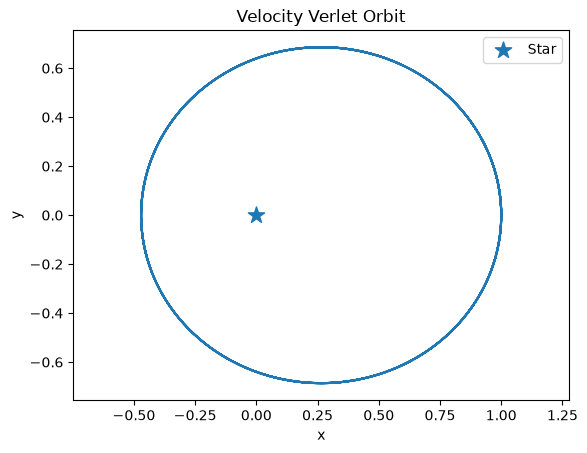

In [4]:
#Part A- Section 4 Confirm it's closed, plot total energy and angular momentum vs time
plt.figure()
plt.plot(rs[:, 0], rs[:, 1])
plt.scatter(0, 0, marker="*", s=150, label="Star")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Velocity Verlet Orbit")
plt.axis("equal")
plt.legend()
plt.show()


In [5]:
#Functions to calculate kinetic energy, potential energy, and angular momentum
def energy(r, v, G=1.0, M=1.0, m=1.0):
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)
    return ke + pe

def ang_momentum(r, v, m=1.0):
    
    return m * (r[0] * v[1] - r[1] * v[0])

In [6]:
#Energies and Momentum for every timestep
energies = []

for r, v in zip(rs, vs):
    energies.append(energy(r, v))

energies = np.array(energies)

angular_momenta = []

for r, v in zip(rs, vs):
    angular_momenta.append(ang_momentum(r, v))

angular_momenta = np.array(angular_momenta)

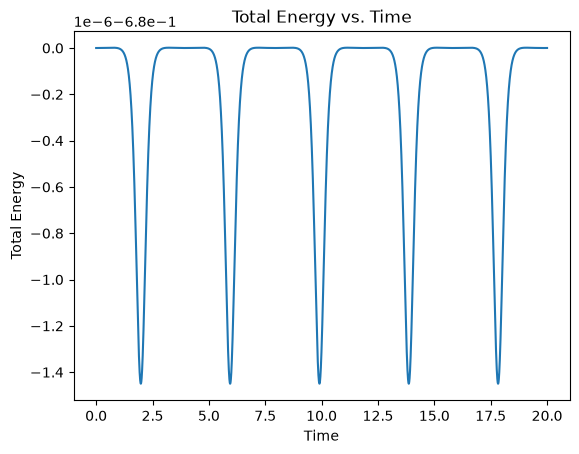

In [7]:
plt.figure()

plt.plot(ts, energies)

plt.xlabel("Time")
plt.ylabel("Total Energy")
plt.title("Total Energy vs. Time")

plt.show()

The total energy remains approximately constant. There appears to be small fluctuations that oscillate on the graph. Due to the scaling of the y-axis, these appear to be large fluctiations but they are actually small fluctuations that the total energy does not steadily increase or decrease which implies that energy is being conserved over time.

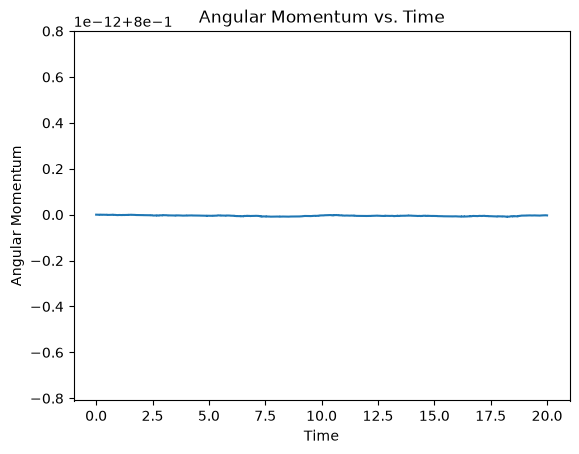

In [8]:
# Angular Momentum vs time plot
plt.figure()

plt.plot(ts, angular_momenta)

plt.xlabel("Time")
plt.ylabel("Angular Momentum")
plt.title("Angular Momentum vs. Time")

plt.show()

The angular momentum with respect to time is approximately flat. There are small fluctuationgs in the graph, but the graph shows that momentum doesn't increase or decrease over time which implies it is generally conserved. 

Part A: Section 5: 
The starting point is apoapsis. If the initial condition is 0.8 instead of 1.0 it means it is less than 1.0. This means the object is not moving fast enough to have a circular orbit at that specific radius so it starts moving towards the central mass. That means it must have started at the farthest point in its elliptical orbit which by definition is apoapsis.

Part B- The Integrator Showdown

In [9]:
#Part B- Section 1: function that can run euler, euler-cromer, and verlet on identical initial conditions

def simulate(method, dt, n_steps):
    r = np.array([1.0, 0.0])
    v = np.array([0.0, 0.8])
    a = accel(r)

    rs = [r.copy()]
    vs = [v.copy()]
    ts = [0.0]

    for step in range(n_steps):

        if method == "euler":
            r_new = r + v * dt
            v_new = v + a * dt
            a_new = accel(r_new)

        elif method == "euler-cromer":
            v_new = v + a * dt
            r_new = r + v_new * dt
            a_new = accel(r_new)

        elif method == "verlet":
            r_new = r + v * dt + 0.5 * a * dt**2
            a_new = accel(r_new)
            v_new = v + 0.5 * (a + a_new) * dt

     
#Store updated values
        r = r_new
        v = v_new
        a = a_new

        rs.append(r.copy())
        vs.append(v.copy())
        ts.append((step + 1) * dt)

    return np.array(ts), np.array(rs), np.array(vs)

In [10]:
# Part B- Section 2: Runs all 3 methods with the same dt for many orbits

#Initial Conditions
dt = 0.001
n_steps = 25000

#Call all 3 methods and store results
t_euler, r_euler, v_euler = simulate("euler", dt, n_steps)
t_ec, r_ec, v_ec = simulate("euler-cromer", dt, n_steps)
t_verlet, r_verlet, v_verlet = simulate("verlet", dt, n_steps)

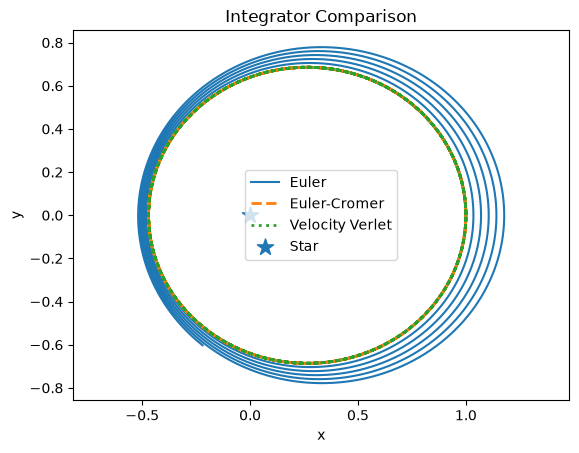

In [11]:
#3 trajectories overlayed
plt.plot(r_euler[:, 0], r_euler[:, 1],
         label="Euler", linewidth=1.5)

plt.plot(r_ec[:, 0], r_ec[:, 1],
         label="Euler-Cromer", linestyle="--", linewidth=2)

plt.plot(r_verlet[:, 0], r_verlet[:, 1],
         label="Velocity Verlet", linestyle=":", linewidth=2)

plt.scatter(0, 0, marker="*", s=150, label="Star")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Integrator Comparison")
plt.axis("equal")
plt.legend()

plt.show()

This plot shows why velocity verlet and euler cromer arethe best numerical techniques for this specific simulation. The euler method spirals out away from the main orbid whereas euler cromer and velocity verlet stay closely bound. 

In [12]:
#Part B- Section 3: Plot energy vs time for all 3 methods on one axis
# Function Calculates energies
def calculate_energies(rs, vs):
    energies = []

    for r, v in zip(rs, vs):
        energies.append(energy(r, v))

    return np.array(energies)

#Calls function for each method
E_euler = calculate_energies(r_euler, v_euler)
E_ec = calculate_energies(r_ec, v_ec)
E_verlet = calculate_energies(r_verlet, v_verlet)



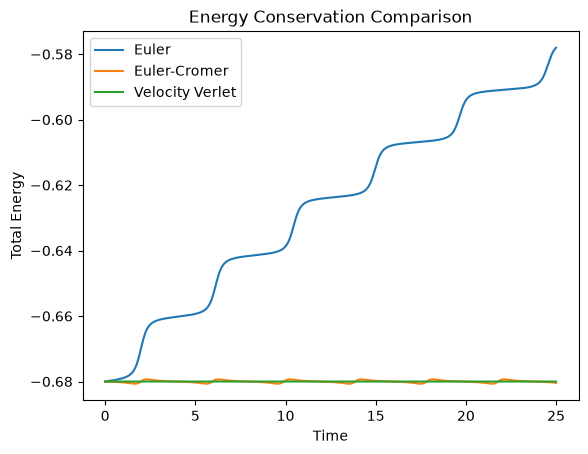

In [13]:
# energy vs time plot for each method (on same axis!)
plt.figure()

plt.plot(t_euler, E_euler, label="Euler")
plt.plot(t_ec, E_ec, label="Euler-Cromer")
plt.plot(t_verlet, E_verlet, label="Velocity Verlet")

plt.xlabel("Time")
plt.ylabel("Total Energy")
plt.title("Energy Conservation Comparison")
plt.legend()


This graphs demonstrates that velocity verlet is the best numerical method for energy conservation. As shown, the velocity verlet (green line) is completely flat whilst euler-cromer slightly fluctuates, and euler increases constantly over time.

In [14]:
#Part B- Section 4: Make a summary table
# Calulates Maximum fractional energy error
def max_fractional_energy_error(energies):
    E0 = energies[0]
    frac_error = np.abs((energies - E0) / E0)
    return np.max(frac_error)

#calculates error for each method and prints them to make sure table values will be correct
error_euler = max_fractional_energy_error(E_euler)
error_ec = max_fractional_energy_error(E_ec)
error_verlet = max_fractional_energy_error(E_verlet)

print("Euler:", error_euler)
print("Euler-Cromer:", error_ec)
print("Velocity Verlet:", error_verlet)

Euler: 0.14995592021420875
Euler-Cromer: 0.0009763462163022773
Velocity Verlet: 2.1318638648521885e-06


In [15]:

summary = pd.DataFrame({
    "Method": ["Euler", "Euler-Cromer", "Velocity Verlet"],
    "Max Fractional Energy Error": [
        error_euler,
        error_ec,
        error_verlet
    ]
})

summary

,Method,Max Fractional Energy Error
0,Euler,0.149956
1,Euler-Cromer,0.000976
2,Velocity Verlet,0.000002


Part B- Section 5: Euler gains  energy because it updates the position and the velocity with the same information from the beginning of that step. The small errors this causes accumulates in the same direction which is why it gains energy over time. This also causes the orbit to spiral outward. Verlet is more stable because the errors it has stay bounded and oscillate rather than steadily accumulating in one direction. Verlet is symplectic which means ait preserves phase space area as well as other geometric structures of the phase space. This makes it better than euler for long term simulations of any systems that conserve energy. 

Part C- Verify Kepler's Three Laws

In [16]:

# Part C - Section 1: Kepler's First Law

#finds distance from every point
distances = np.linalg.norm(r_verlet, axis=1)

r_min = np.min(distances)
r_max = np.max(distances)

a_semimajor = (r_min + r_max) / 2

# Prints results based on what was requested in assignment
print("Minimum radius:", r_min)
print("Maximum radius:", r_max)
print("Semi-major axis:", a_semimajor)

Minimum radius: 0.47058912735583197
Maximum radius: 1.0
Semi-major axis: 0.735294563677916


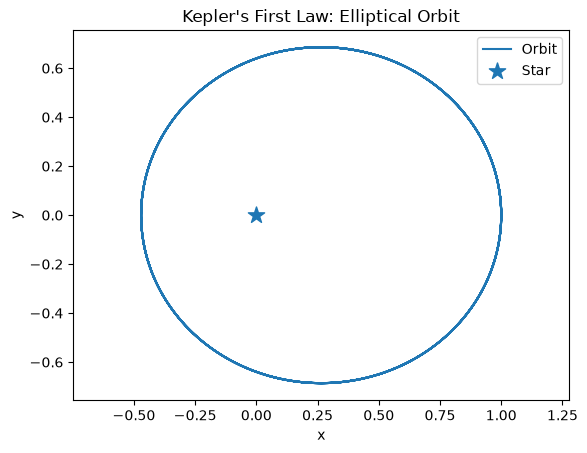

In [17]:
# Orbit plot
plt.figure()

plt.plot(r_verlet[:, 0], r_verlet[:, 1], label="Orbit")
plt.scatter(0, 0, marker="*", s=150, label="Star")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Kepler's First Law: Elliptical Orbit")
plt.axis("equal")
plt.legend()

plt.show()

This plot of the simulation of the elliptical orbit is consistent with what you would expect if the simulation followed Kepler's First Law. As shown, the central star is located at a focus of the ellipse instead of its center. When the object is on the right side of the orbit (where the blue line is to the right of the star), it is at apoapsis (which is the farthest point) and at periapsis on the left side, where it's closes to the star. 

In [18]:
#Part C- Section 2 : Second law (equal areas)

#Computes area swept per time
areas = []

for r, v in zip(r_verlet, v_verlet):
    cross = r[0] * v[1] - r[1] * v[0]
    dA = 0.5 * abs(cross) * dt
    areas.append(dA)

areas = np.array(areas)

In [19]:
#Plots area vs time

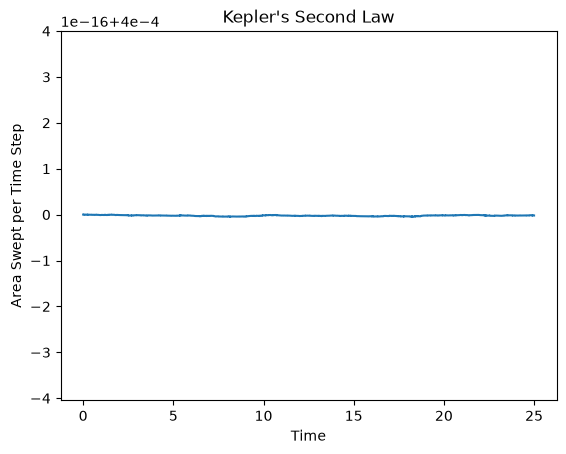

In [20]:
plt.figure()

plt.plot(t_verlet, areas)

plt.xlabel("Time")
plt.ylabel("Area Swept per Time Step")
plt.title("Kepler's Second Law")

plt.show()

The area swept per time step remains approximately constant over time which means the simulation follows kepler's second law. The tiny fluctuations are mostly due to rounding and other precision erros.

In [21]:
#Part C- Section 3: Third Law

In [22]:
def simulate(method, dt, n_steps, v0=0.8):
    r = np.array([1.0, 0.0])
    v = np.array([0.0, v0])
    a = accel(r)

    rs = [r.copy()]
    vs = [v.copy()]
    ts = [0.0]

    for step in range(n_steps):

        if method == "euler":
            r_new = r + v * dt
            v_new = v + a * dt
            a_new = accel(r_new)

        elif method == "euler-cromer":
            v_new = v + a * dt
            r_new = r + v_new * dt
            a_new = accel(r_new)

        elif method == "verlet":
            r_new = r + v * dt + 0.5 * a * dt**2
            a_new = accel(r_new)
            v_new = v + 0.5 * (a + a_new) * dt

        else:
            raise ValueError("Unknown method")

        r = r_new
        v = v_new
        a = a_new

        rs.append(r.copy())
        vs.append(v.copy())
        ts.append((step + 1) * dt)

    return np.array(ts), np.array(rs), np.array(vs)

In [23]:
v0_values = [0.70, 0.75, 0.80, 0.85, 0.90]

In [24]:
a_values = []
T_values = []

for v0 in v0_values:

    ts, rs, vs = simulate(
        "verlet",
        dt=0.001,
        n_steps=20000,
        v0=v0
    )

    # Semi-major axis
    distances = np.linalg.norm(rs, axis=1)

    r_min = np.min(distances)
    r_max = np.max(distances)

    a = (r_min + r_max) / 2

    # Find upward y=0 crossings
    crossing_times = []

    for i in range(1, len(rs)):
        if (
            rs[i-1, 1] < 0
            and rs[i, 1] >= 0
            and vs[i, 1] > 0
        ):
            crossing_times.append(ts[i])

    T = crossing_times[0]

    a_values.append(a)
    T_values.append(T)
a_values = np.array(a_values)
T_values = np.array(T_values)

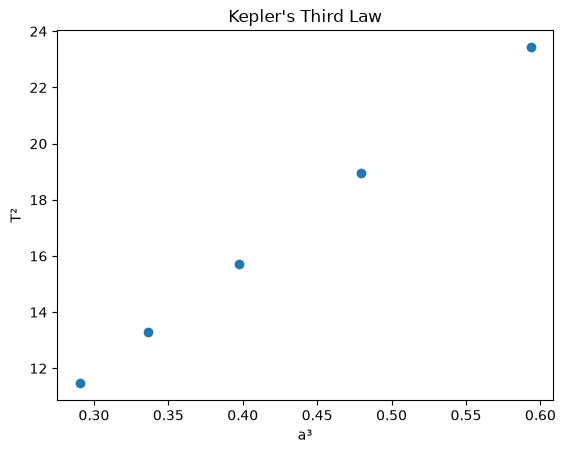

Measured slope: 39.490248786961295
Intercept: -0.0002028974078426661


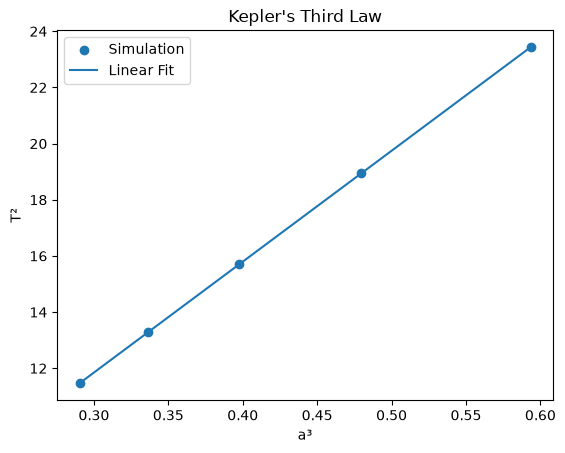

Expected slope: 39.47841760435743


In [25]:
a_cubed = a_values**3
T_squared = T_values**2

plt.figure()

plt.scatter(a_cubed, T_squared)

plt.xlabel("a³")
plt.ylabel("T²")
plt.title("Kepler's Third Law")

plt.show()

slope, intercept = np.polyfit(a_cubed, T_squared, 1)

print("Measured slope:", slope)
print("Intercept:", intercept)
fit = slope * a_cubed + intercept

plt.figure()

plt.scatter(a_cubed, T_squared, label="Simulation")
plt.plot(a_cubed, fit, label="Linear Fit")

plt.xlabel("a³")
plt.ylabel("T²")
plt.title("Kepler's Third Law")
plt.legend()

plt.show()
expected_slope = 4 * np.pi**2 / (G * M)

print("Expected slope:", expected_slope)

The measured/numerically calculated slopes agree with theory predicted by keplers laws very well. A lot of the small differences compared to this simualted value and the expected theoretical values can be attributed to other errors like rounding and precision which are reflective of the computational method itself not the equations. The step size can also change the amount of error, the smaller the step size, the more accurate the simulations are (the closer they are to the theoretical values).

Bonus- True Two-Body Option

In [26]:
#Initial Parmaters

G = 1.0
m1 = 1.0
m2 = 0.8

r1 = np.array([-0.4, 0.0])
r2 = np.array([ 0.5, 0.0])
v1 = np.array([0.0, -0.45])
v2 = np.array([0.0,  0.5625])

dt = 0.001
n_steps = 20000

In [27]:
#Calculating acceleration
def two_body_accel(r1, r2, m1, m2):
    dr = r2 - r1
    dist = np.linalg.norm(dr)

    a1 = G * m2 * dr / dist**3
    a2 = -G * m1 * dr / dist**3

    return a1, a2

In [28]:
#Velocity Verlet technique from assignment
a1, a2 = two_body_accel(r1, r2, m1, m2)

r1_history = [r1.copy()]
r2_history = [r2.copy()]

com_history = []

for _ in range(n_steps):

    # update positions
    r1_new = r1 + v1 * dt + 0.5 * a1 * dt**2
    r2_new = r2 + v2 * dt + 0.5 * a2 * dt**2

    # new accelerations
    a1_new, a2_new = two_body_accel(
        r1_new, r2_new, m1, m2
    )

    # update velocities
    v1_new = v1 + 0.5 * (a1 + a1_new) * dt
    v2_new = v2 + 0.5 * (a2 + a2_new) * dt

    # advance system
    r1 = r1_new
    r2 = r2_new
    v1 = v1_new
    v2 = v2_new
    a1 = a1_new
    a2 = a2_new

    r1_history.append(r1.copy())
    r2_history.append(r2.copy())

    com = (m1 * r1 + m2 * r2) / (m1 + m2)
    com_history.append(com.copy())

#Putting the info into arrays
r1_history = np.array(r1_history)
r2_history = np.array(r2_history)
com_history = np.array(com_history)

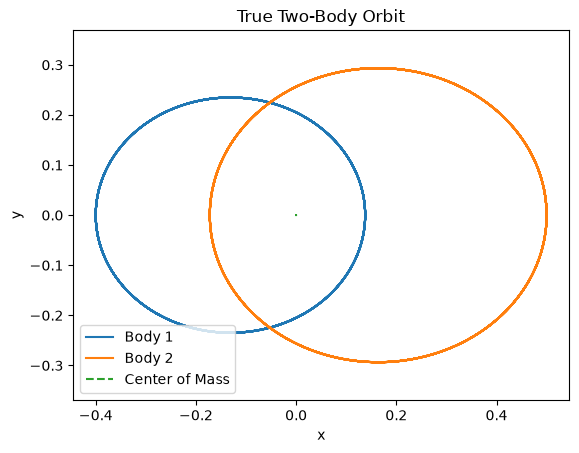

In [29]:
#Plotting both trajectories and center of mass
plt.figure()

plt.plot(
    r1_history[:, 0],
    r1_history[:, 1],
    label="Body 1"
)

plt.plot(
    r2_history[:, 0],
    r2_history[:, 1],
    label="Body 2"
)

plt.plot(
    com_history[:, 0],
    com_history[:, 1],
    "--",
    label="Center of Mass"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("True Two-Body Orbit")
plt.axis("equal")
plt.legend()

plt.show()


In this true body simulation, both of the objects are moving around their shared center of mass. The bigger body has a smaller orbit whilst the smaller body follows the larger orbit. The center of mass appears to remain mostly stationary throughout the motion which matches the idea that momentum should be conserved in an isolated two body sytem. 